In [2]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [3]:
def visualize_coco(coco_json_path):
    with open(coco_json_path, "r") as f:
        data = json.load(f)

    # Create lookup for images
    images = {img["id"]: img for img in data["images"]}

    for ann in data["annotations"]:
        img_meta = images.get(ann["image_id"])
        if not img_meta:
            continue

        img_path = img_meta["path"]
        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue

        img = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(img)

        # COCO segmentation is a list of polygons (list of lists)
        for poly in ann["segmentation"]:
            # Convert flat [x1, y1, x2, y2...] to list of tuples [(x1,y1), (x2,y2)...]
            points = [(poly[i], poly[i + 1]) for i in range(0, len(poly), 2)]
            draw.polygon(points, outline="red", width=3)

        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.title(f"Annotation: {ann['id']}")
        plt.axis("off")
        plt.show()

/mnt/c/Users/User/Documents/ManthanShala/v18hub/Projects/intraoral_leison/SMART II Dataset/Normal/SMITA00363/coco_json/SMITA00363_R_DT.json


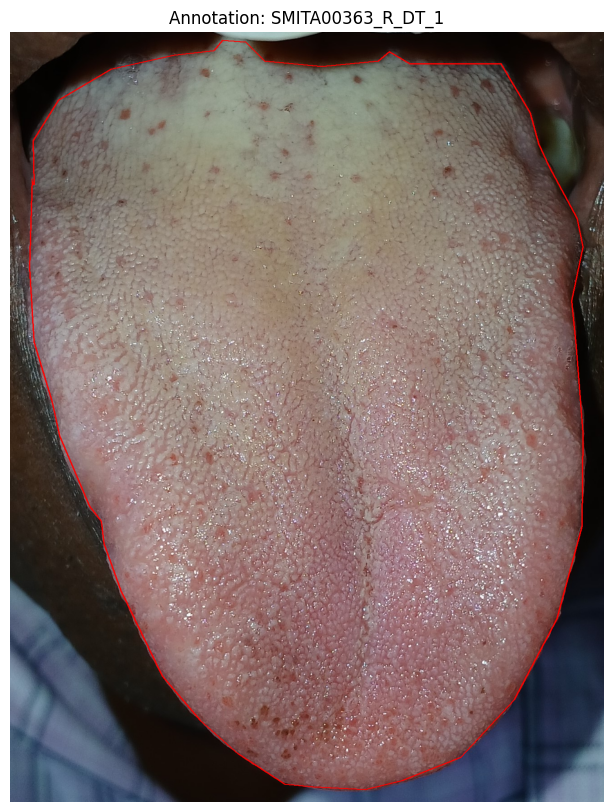

In [9]:
coco_dataset = pd.read_csv("../../../data/temp_coco_dataset.csv")
coco_json = list(coco_dataset.coco_file.values)
print(coco_json[0])
visualize_coco(coco_json[0])